<a href="https://colab.research.google.com/github/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/HW_2_5_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/content/train.csv.zip')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

In [2]:
data.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



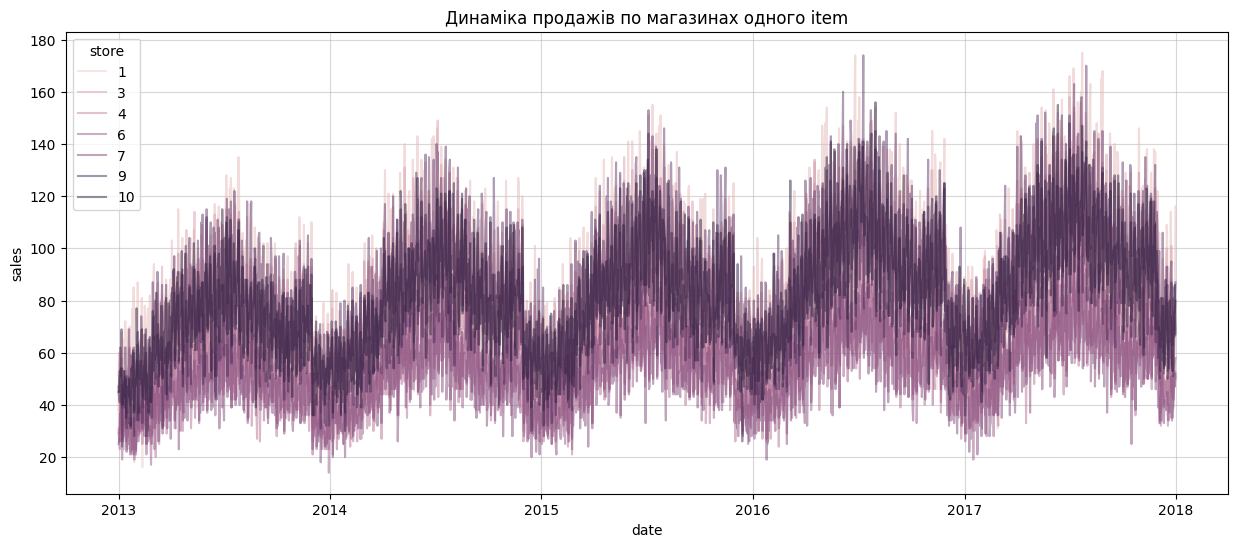

In [3]:
item = 10
data_item = data[data['item'] == item]

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=data_item,
    x='date',
    y='sales',
    hue='store',
    alpha=0.5
)

plt.title(f'Динаміка продажів по магазинах одного item')
plt.xlabel('date')
plt.ylabel('sales')
plt.grid(True, alpha=0.5)
plt.show()

***Висновок***:
 - Диинаміка продажів між магазинами для обраного дуже схожа.Спостерігається подібність в сезонності  і  напрямку тренду. Різниця фактично в масштабах продажів.

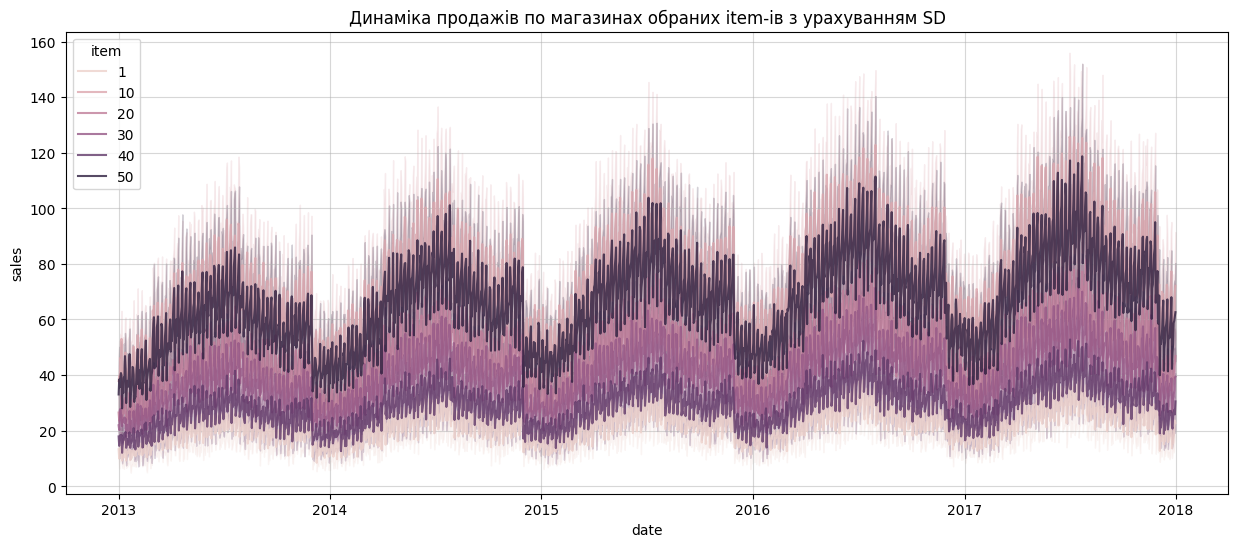

In [4]:
items = [1, 10, 20, 30, 40, 50]
subset = data[data['item'].isin(items)]

plt.figure(figsize=(15, 6))
sns.lineplot(data=subset,
             x='date',
             y='sales',
             hue='item',
             errorbar='sd',
             alpha=0.8)
plt.title(f'Динаміка продажів по магазинах обраних item-ів з урахуванням SD')
plt.ylabel('sales')
plt.xlabel('date')
plt.grid(True, alpha=0.5)
plt.show()

***Висновок:***
 - Диинаміка продажів між магазинами для обраних товарів дуже схожа.Спостерігається подібність в сезонності  і  напрямку тренду. Різниця фактично в масштабах продажів.

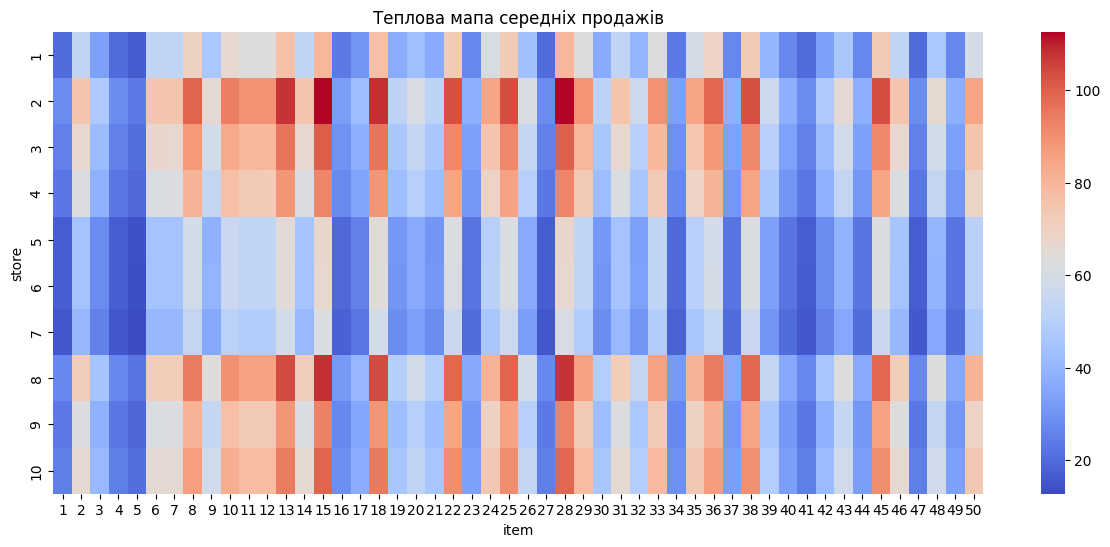

In [5]:
grouped = data.groupby(['store', 'item'])['sales'].mean().unstack()

plt.figure(figsize=(15, 6))
sns.heatmap(grouped, cmap='coolwarm')

plt.title('Теплова мапа середніх продажів')
plt.xlabel('item')
plt.ylabel('store')
plt.show()

***Висновок:***
- На тепловій мапі спостерігаютсья товари, які стабільно погано/добре продаються по всіх магазинах. Наприклад, стабільно добре продаютсья 13 та 15 товари. Стабільно погано продаються товари 1, 4,5 41. Також на тепловій мапі можна виділити магазини 2 та 8, як більш успішні в продажах.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

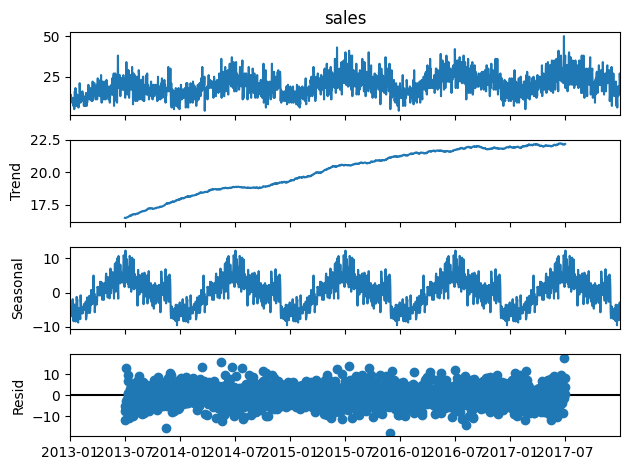

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

item1 = data[(data['item'] == 1) & (data['store'] == 1)].copy()
decomposition_plot_multi = seasonal_decompose(item1['sales'],
                                              model='additive',
                                              period=365 )
decomposition_plot_multi.plot()
plt.show()

***Висновок:***
- З вказівкою параметр period=365 в порівнянні з графіком без цього параметру, отримали більш зрозумілий графі.
- По графіку тренду спостерігається чітко виражений висхідний тренд.
- По граіку сезонності спостерігаються сезонні колтвання в продажах.
- По графіку резидулів спостерігається концентрація залишків хмарою навколо нуля.

Для поліпше розуміння цих візуалізацій було б добре провести группування даних не по днях, а по тижнях або місяцях. Це допомогло б чіткіше відобразити сезонність без зайвого шуму.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [7]:
!pip install darts --quiet

In [8]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(item1, value_cols='sales')
series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

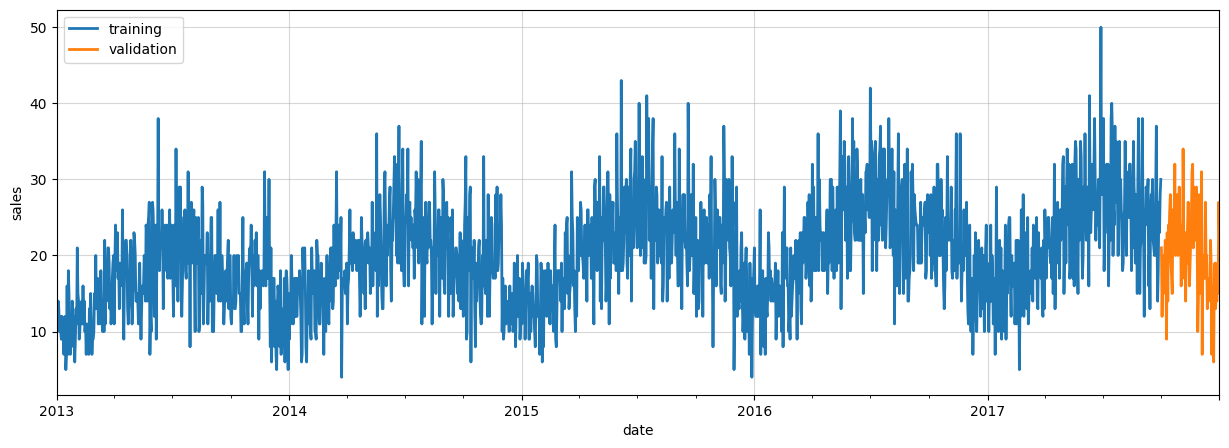

In [9]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))

plt.figure(figsize=(15, 5))
plt.title("Train / Validation split")
train.plot(label="training")
val.plot(label="validation")
plt.xlabel("date")
plt.ylabel("sales")
plt.grid(True, alpha=0.5)
plt.show()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1500x600 with 0 Axes>

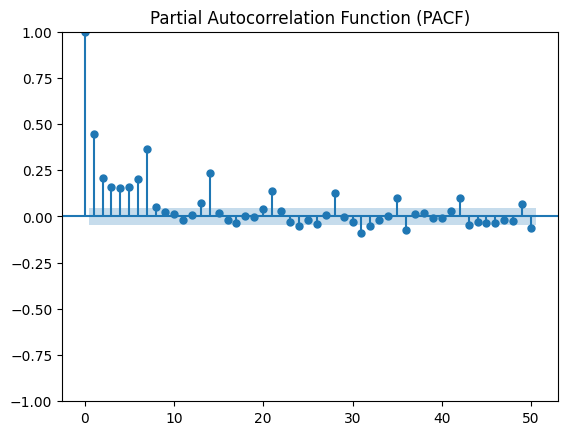

In [10]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(15, 6))
plot_pacf(item1['sales'], lags=50, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

***Висновок:***
- На графіку видно, що впливими лагами є:

      - в більшій мірі 1-й, 7-й та 14-й;
      - значущими, але в меншій мірі лаги з 2-го по 6-й, та лаги 21, 28.

Спостерігається тижнева сезонність.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [11]:
from darts.utils.statistics import  check_seasonality

for m in range(2, 25):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [12]:
!pip install pytorch-lightning --quiet

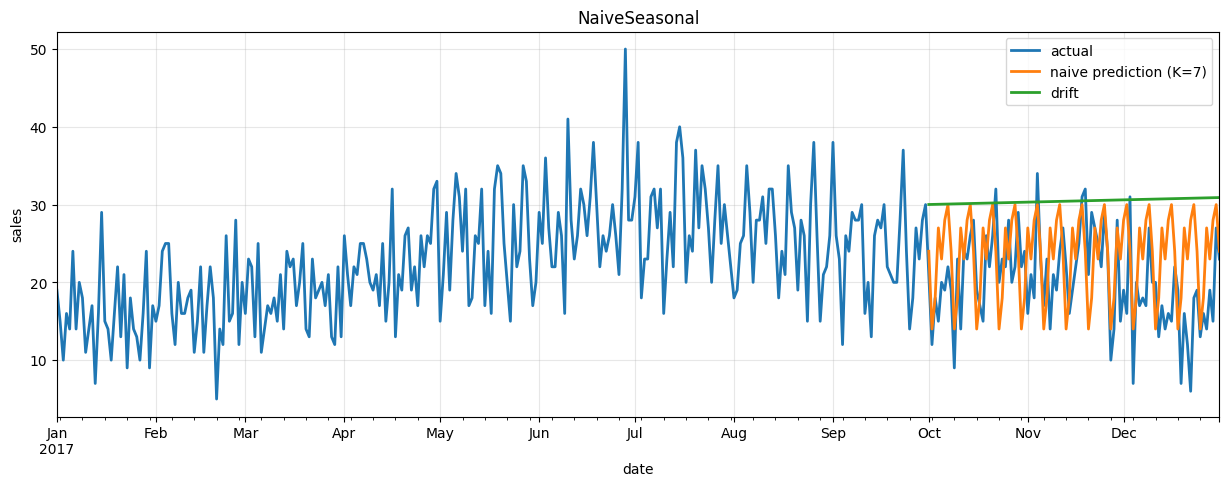

In [13]:
from darts.models import NaiveSeasonal, NaiveDrift

n = len(val)

naive_model = NaiveSeasonal(K=7)
naive_model.fit(train)
naive_forecast = naive_model.predict(n)

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(n)


plt.figure(figsize=(15, 5))
series[-365:].plot(label="actual") # с тренувального набору взяв рік, оскльки графік виходив нечитабельним
naive_forecast.plot(label="naive prediction (K=7)")
drift_forecast.plot(label="drift")

plt.title('NaiveSeasonal')
plt.xlabel("date")
plt.ylabel("sales")
plt.grid(True, alpha=0.3)
plt.show()

 NaiveSeasonal непогано відтворила тижневі коливання, але схоже, що сезонні коливання не враховані. NaieDrift виявилася найгіршою, оскільки просто відобразила лінію.

 Як варіант можна розглянути річну сезонність. В завданні №3 вже використовували цю періодичність.

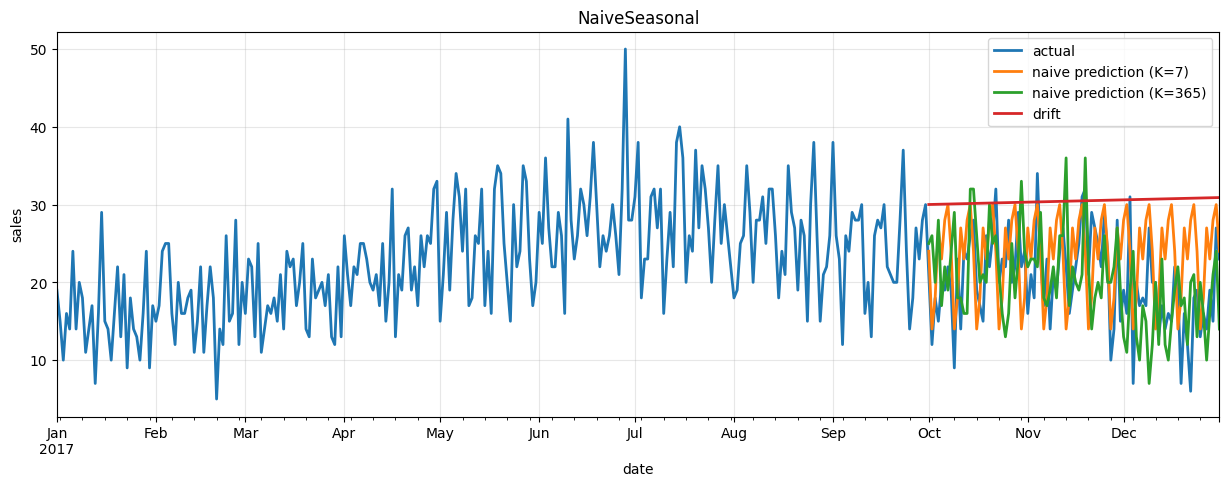

In [14]:
naive_model_365 = NaiveSeasonal(K=365)
naive_model_365.fit(train)
naive_forecast_365 = naive_model_365.predict(n)


plt.figure(figsize=(15, 5))
series[-365:].plot(label="actual") # с тренувального набору взяв рік, оскльки графік виходив нечитабельним
naive_forecast.plot(label="naive prediction (K=7)")
naive_forecast_365.plot(label="naive prediction (K=365)")
drift_forecast.plot(label="drift")

plt.title('NaiveSeasonal')
plt.xlabel("date")
plt.ylabel("sales")
plt.grid(True, alpha=0.3)
plt.show()

Рузльтат з NaiveSeasonal(K=365) показав себе краще.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [15]:
from darts.metrics import mape

def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

eval_forecast(naive_model, val, naive_forecast)
eval_forecast(drift_model, val, drift_forecast)
eval_forecast(naive_model_365, val, naive_forecast_365)

model NaiveSeasonal(K=7) obtains MAPE: 38.17%
model NaiveDrift() obtains MAPE: 68.74%
model NaiveSeasonal(K=365) obtains MAPE: 33.92%


np.float64(33.92273524939832)

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [16]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

def enrich_with_date_features(df):
    df["dayofweek"] = df['date'].dt.dayofweek
    df["quarter"] = df['date'].dt.quarter
    df["month"] = df['date'].dt.month
    df["year"] = df['date'].dt.year
    df["dayofyear"] = df['date'].dt.dayofyear
    df["sin_day"] = np.sin(df["dayofyear"])
    df["cos_day"] = np.cos(df["dayofyear"])
    df["dayofmonth"] = df['date'].dt.day
    return df

train_df = enrich_with_date_features(train.to_dataframe().reset_index())
val_df = enrich_with_date_features(val.to_dataframe().reset_index())

feature_cols = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'sin_day', 'cos_day', 'dayofmonth']

train_features = TimeSeries.from_dataframe(train_df, time_col='date', value_cols=feature_cols)
val_features = TimeSeries.from_dataframe(val_df, time_col='date', value_cols=feature_cols)
all_features = train_features.append(val_features)

xgb_model = XGBModel(
    lags=7,
    output_chunk_length=1,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    lags_future_covariates=[0],
    random_state=42
)

# ← train без масштабування
xgb_model.fit(train, future_covariates=all_features)
xgb_forecast = xgb_model.predict(n, future_covariates=all_features)

eval_forecast(xgb_model, val, xgb_forecast)

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 22.53%


np.float64(22.532230684913994)

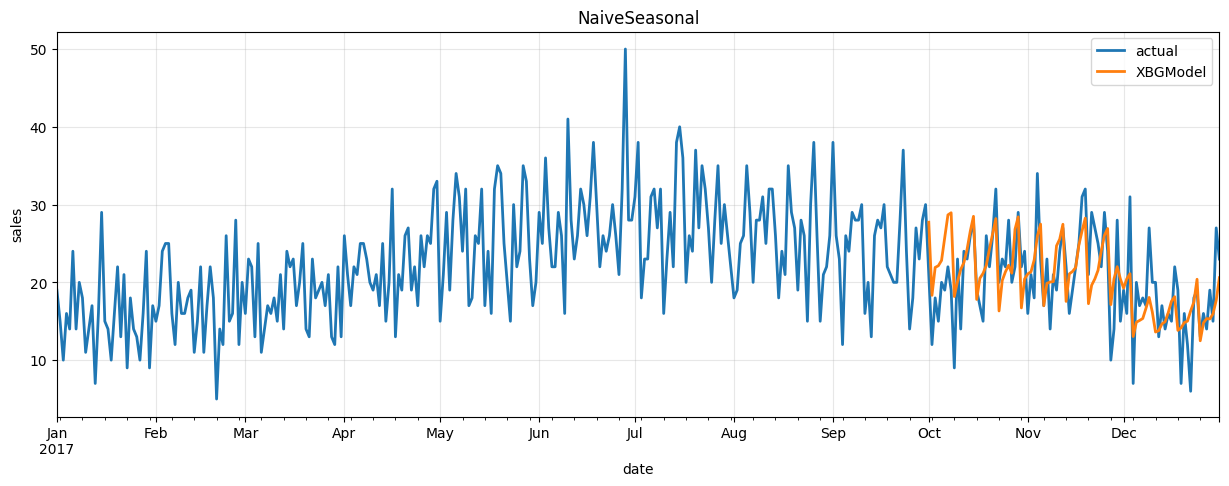

In [17]:
def plot_model(model_forecast, model_name="Model"):

  plt.figure(figsize=(15, 5))
  series[-365:].plot(label="actual") # с тренувального набору взяв рік, оскльки графік виходив нечитабельним
  model_forecast.plot(label=model_name)
  plt.title('NaiveSeasonal')
  plt.xlabel("date")
  plt.ylabel("sales")
  plt.grid(True, alpha=0.3)
  plt.show()

plot_model(xgb_forecast, 'XBGModel')

***Висновок:***
- Модель XBGModel з додаванням додаткових ознак та масштабуванням показала непоганий результат. Значення MAPE є поки найкращим серед розглянутих моделей.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

model ExponentialSmoothing() obtains MAPE: 39.01%


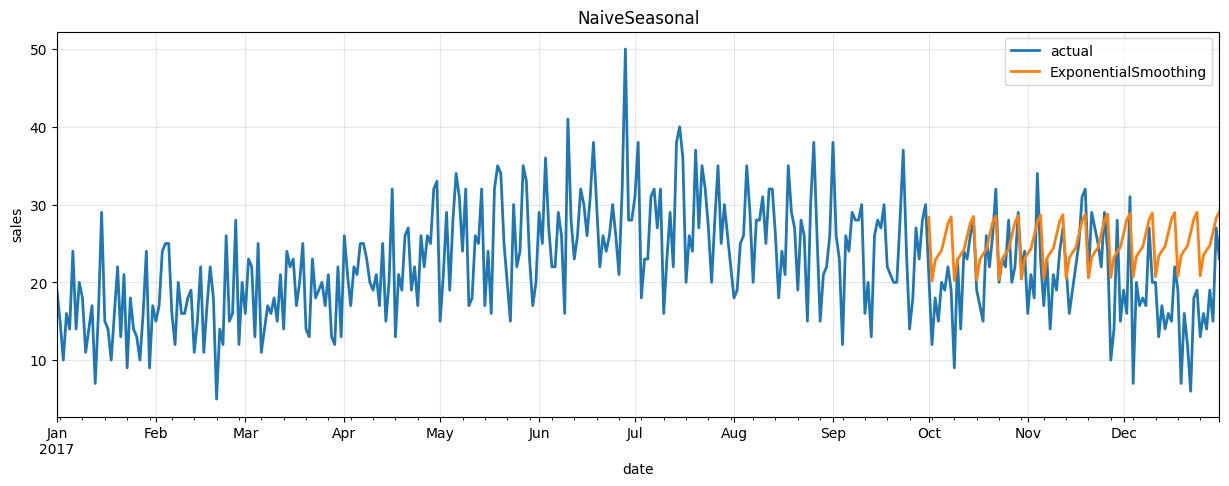

In [18]:
from darts.models import ExponentialSmoothing

es_model = ExponentialSmoothing()
es_model.fit(train)
es_forecast = es_model.predict(len(val))

eval_forecast(es_model, val, es_forecast)
plot_model(es_forecast, 'ExponentialSmoothing')

***Висновок:***
- Модель показала поганий результат. Значення MAPE на рівні показників наївних моделей.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


model ARIMA(p=7, q=1) obtains MAPE: 39.53%


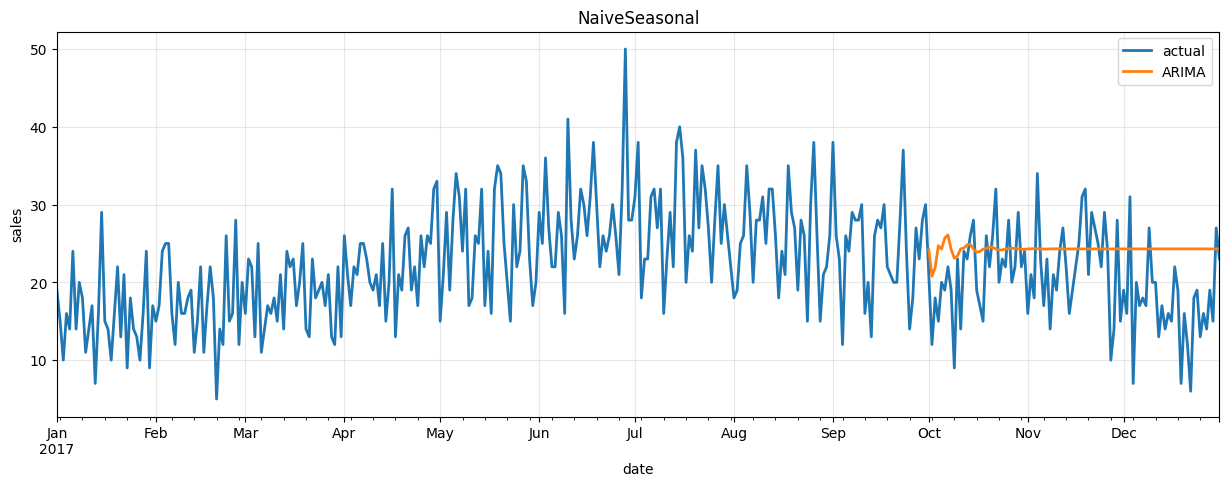

In [19]:
from darts.models import ARIMA

arima_model = ARIMA(p=7, d=1, q=1)
arima_model.fit(train)
arima_forecast = arima_model.predict(len(val))

eval_forecast(arima_model, val, arima_forecast)
plot_model(arima_forecast, 'ARIMA')


***Висновок:***
- Модель показала поганий результат. Значення MAPE на рівні показників наївних моделей.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [20]:
!pip install statsforecast --quiet

model AutoARIMA() obtains MAPE: 40.29%


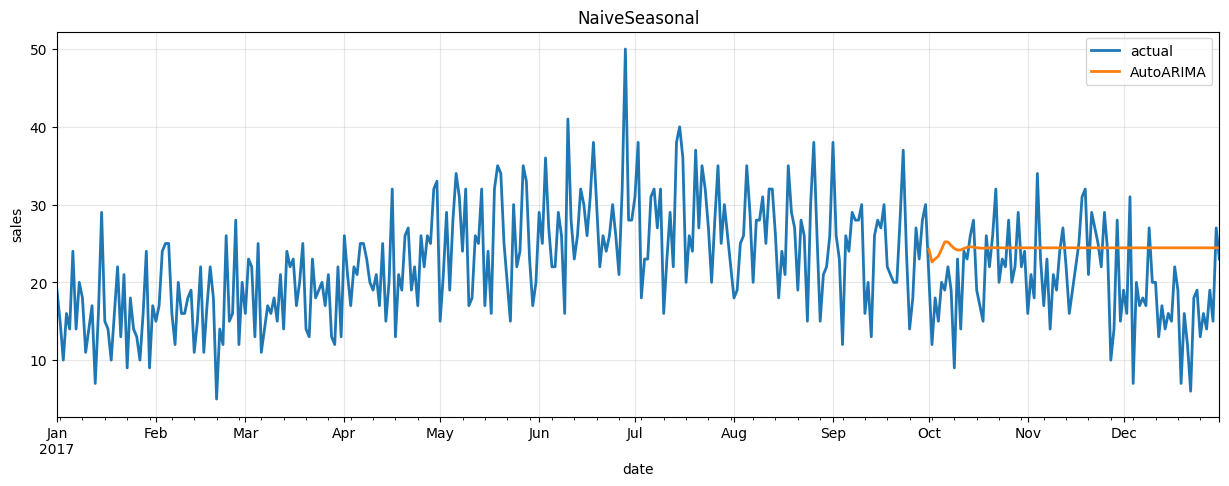

Оптимальні параметри: p=5, d=1, q=2


In [21]:
from darts.models import AutoARIMA

auto_arima_model = AutoARIMA()
auto_arima_model.fit(train)
auto_arima_forecast = auto_arima_model.predict(len(val))

eval_forecast(auto_arima_model, val, auto_arima_forecast)
plot_model(auto_arima_forecast, 'AutoARIMA')

arma = auto_arima_model.model.model_['arma']

print(f"Оптимальні параметри: p={arma[0]}, d={arma[5]}, q={arma[1]}")

***Висновок:***
- Модель показала поганий результат (навіть гірше ніж ARIMA). Значення MAPE на рівні показників наївних моделей.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


model Prophet() obtains MAPE: 23.80%


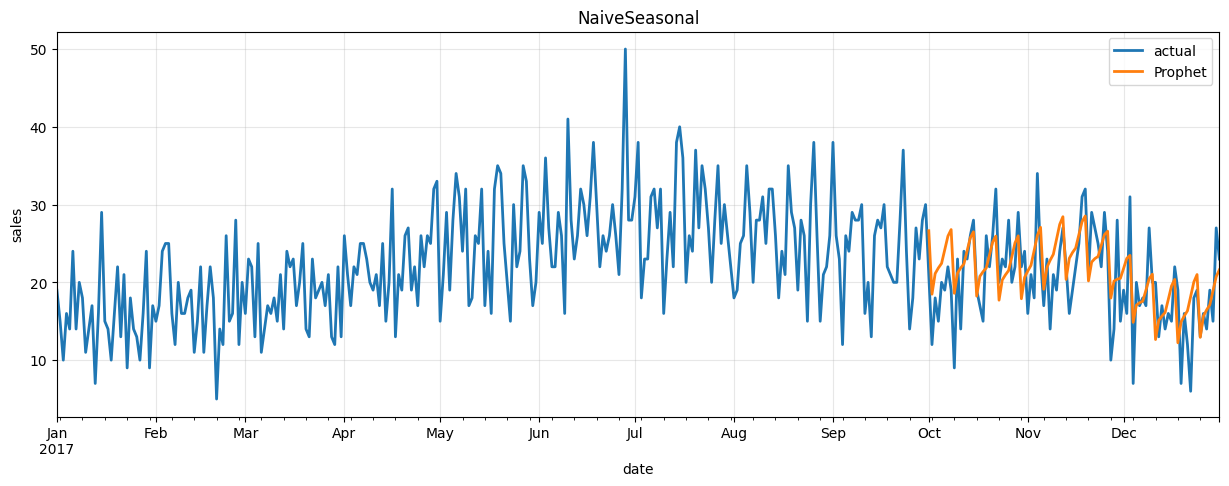

In [22]:
from darts.models import Prophet

prophet_model = Prophet()
prophet_model.fit(train)

prophet_forecast = prophet_model.predict(len(val))

eval_forecast(prophet_model, val, prophet_forecast)
plot_model(prophet_forecast, 'Prophet')

***Висновок:***
- Модель показала непоганий результат. Значення MAPE на рівні показників моделі XBGModel.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  2.8 K │ train │     0 │
│ 6 │ V               │ Linear           │     26 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

model RNNModel(model=LSTM, training_length=28, input_chunk_length=14, n_epochs=100, random_state=42) obtains MAPE: 26.16%


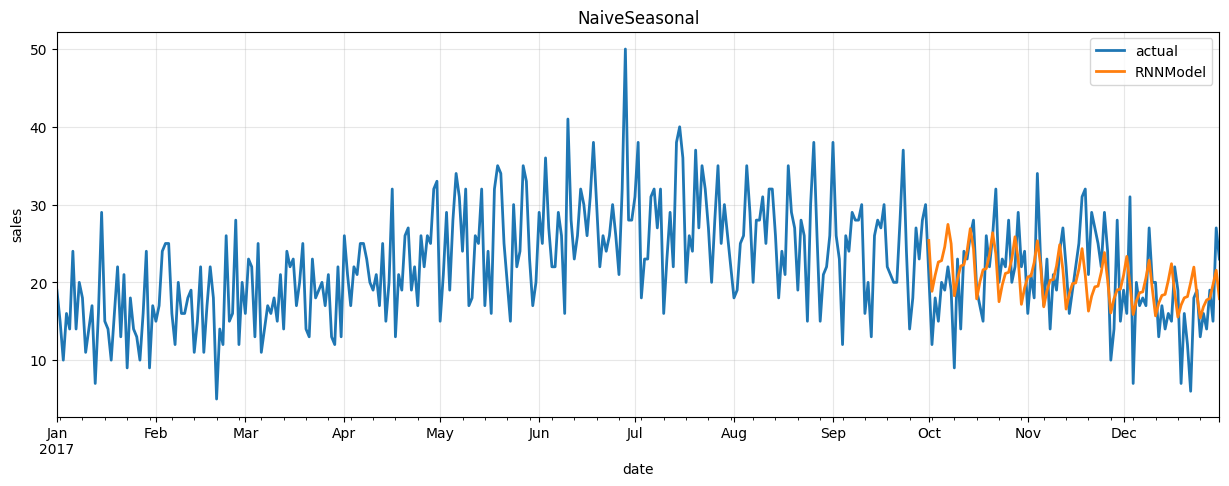

In [23]:
from darts.models import RNNModel

rnn_model = RNNModel(model='LSTM',
                     input_chunk_length=14,
                     training_length=28,
                     n_epochs=100,
                     random_state=42)

scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

rnn_model.fit(train_scaled)
pred = rnn_model.predict(len(val))
rnn_forecast = scaler.inverse_transform(pred)

eval_forecast(rnn_model, val, rnn_forecast)
plot_model(rnn_forecast, 'RNNModel')

***Висновок:***
- Модель показала непоганий результат в порівнянні з іншими моделями. Значення MAPE на рівні показників моделей XBGModel та Prophet.



16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

XBGModel - наша найкраща модель.

historical forecasts: 100%|██████████| 12/12 [00:00<00:00, 13.38it/s]


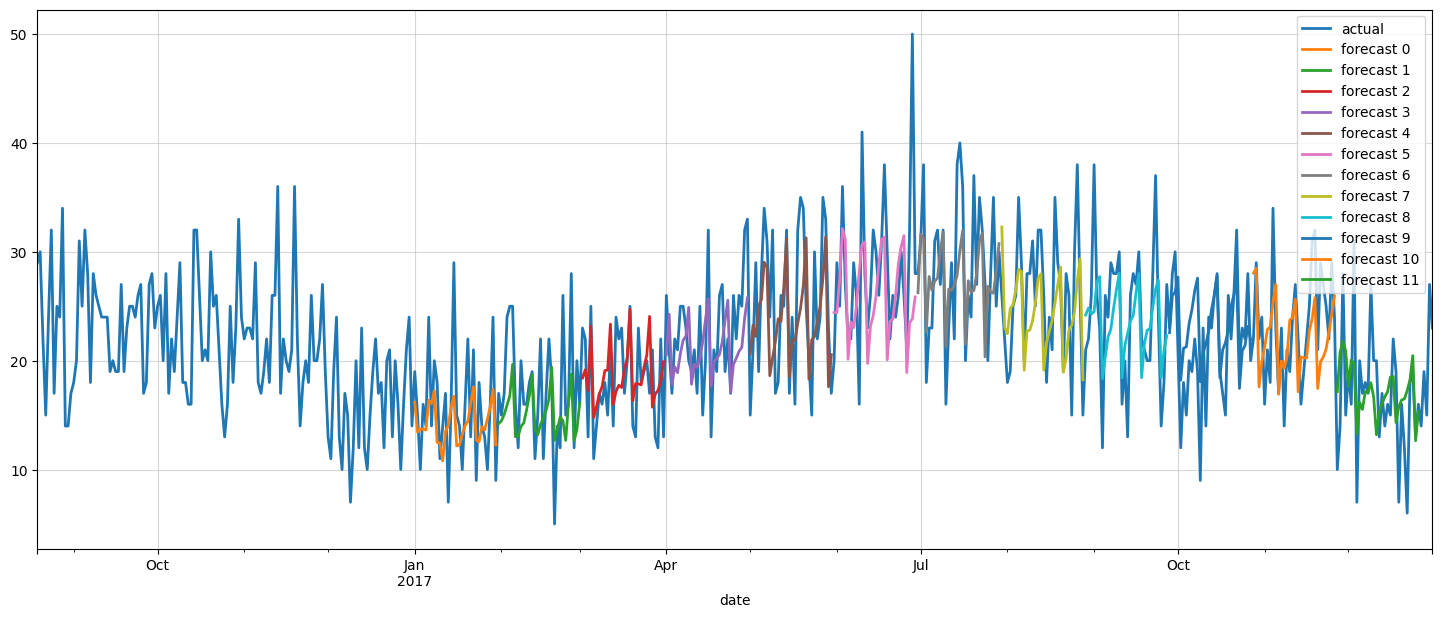

Місяць 1: MAPE = 23.63%
Місяць 2: MAPE = 21.95%
Місяць 3: MAPE = 19.00%
Місяць 4: MAPE = 16.44%
Місяць 5: MAPE = 19.70%
Місяць 6: MAPE = 16.87%
Місяць 7: MAPE = 14.68%
Місяць 8: MAPE = 16.12%
Місяць 9: MAPE = 17.19%
Місяць 10: MAPE = 20.54%
Місяць 11: MAPE = 16.50%
Місяць 12: MAPE = 31.30%


In [24]:
hfc_params = {
    'series': series,
    'future_covariates': all_features,
    'start': pd.Timestamp("2017-01-01"),
    'forecast_horizon': 30,
    'stride': 30,
    'verbose': True
}

historical_fcast = xgb_model.historical_forecasts(last_points_only=False, **hfc_params)

plt.figure(figsize=(18, 7))
series[-500:].plot(label="actual")
for idx, hfc in enumerate(historical_fcast):
    hfc.plot(label=f"forecast {idx}")
plt.grid(True, alpha=0.5)
plt.show()

for idx, hfc in enumerate(historical_fcast):
    s = series.slice_intersect(hfc)
    print(f"Місяць {idx+1}: MAPE = {mape(s, hfc):.2f}%")


Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

***Відповідь:***

Для задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів, я б використовував би модель XBGModel, оскільки вона виявилася переможцем серед розглянутих моделей.
Щодо кількості задіяних моделей, я би розглядав варіант навчання однієї моделі, але для всіх магазинів та товарів. Адже навчати 500 моделей буде занадто витратно по часу та ресурасам.



In [26]:
from google.colab import output
output.clear()